# TENG 手势识别 — 完整分析流程

本 notebook 覆盖从原始数据到最终结果的完整流程：

1. **数据集探索**：三场景样本分布、手势类别统计
2. **原始信号可视化**：各手势波形、三场景对比
3. **预处理展示**：带通滤波、归一化、包络提取
4. **VMD 分解可视化**：变分模态分解的 4 个 IMF 模态
5. **小波包能量可视化**：各子带能量分布
6. **特征体系说明**：373 维特征的构成与重要性
7. **模型训练说明**：架构介绍（如需重新训练可运行）
8. **测试结果分析**：三场景独立评估、混淆矩阵、置信度分析

**运行环境**：Kernel 选择 `zw@TENG-GestureClassifier`

## 1. 环境初始化

In [1]:
%matplotlib inline
import sys, math, random, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

PROJECT_ROOT = Path('../').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import joblib

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False

COLORS = {'base': '#4C72B0', 'wind_noise': '#DD8452', 'uv_radiation': '#55A868'}
ENV_LABELS = {'base': 'Normal', 'wind_noise': 'Wind Noise', 'uv_radiation': 'UV Radiation'}
GESTURE_NAMES = ['1','2','3','4','5','go_the_way','ok','sc','stop','wave']
PALETTE = sns.color_palette('tab10', n_colors=10)
FS = 1000  # sampling rate

meta = pd.read_csv(PROJECT_ROOT / 'data/processed/features/all_features.csv')
meta = meta[meta['duration_ms'] >= 200].reset_index(drop=True)
print(f'Total samples: {len(meta)}  |  Classes: {meta["gesture_name"].nunique()}  |  Scenes: {meta["env"].nunique()}')

Total samples: 1175  |  Classes: 10  |  Scenes: 3


## 2. 数据集统计

TENG 传感器数据共包含三个采集场景，10 类手势，合计 1175 个有效片段（时长 ≥ 200ms）。

- **标准环境（base）**：934 个，实验室标准条件，主力数据
- **风噪环境（wind_noise）**：174 个，60-85 dB 风声干扰
- **紫外环境（uv_radiation）**：67 个，40mm 紫外辐射 30 分钟暴露

下图展示三个维度的分布：场景占比、各手势在三场景中的样本量、段时长分布。

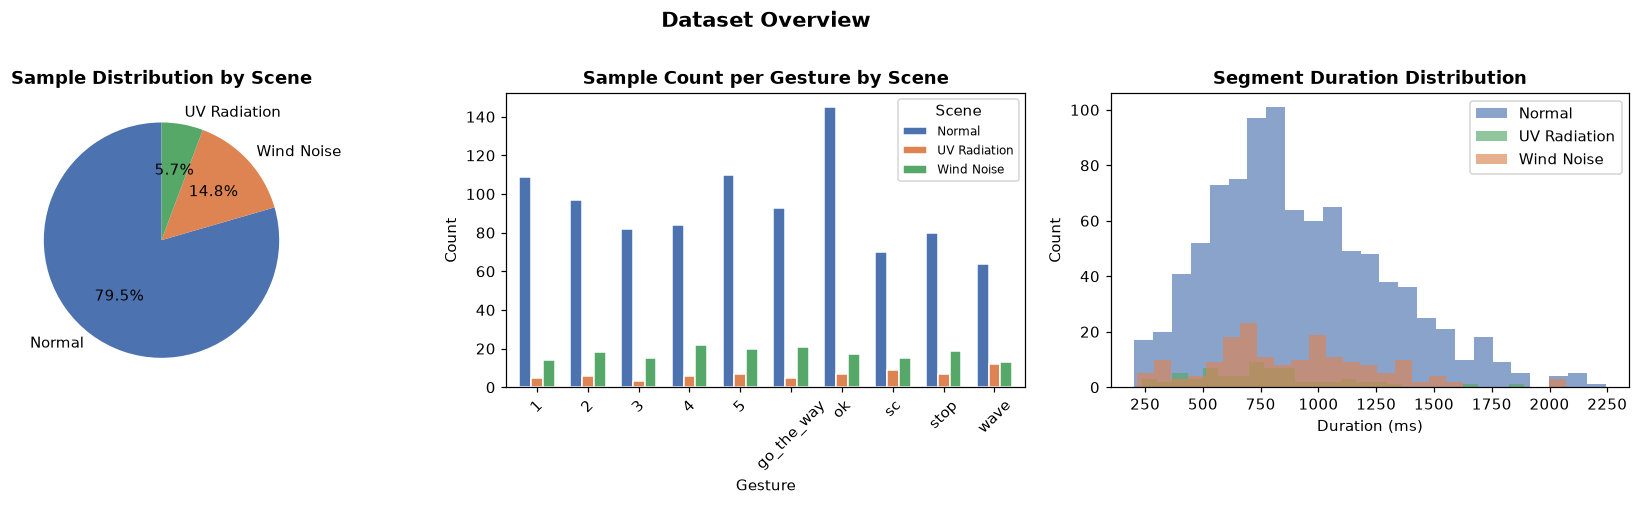

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 场景分布饼图
env_counts = meta['env'].value_counts()
labels_cn = [ENV_LABELS[e] for e in env_counts.index]
axes[0].pie(env_counts.values, labels=labels_cn, autopct='%1.1f%%',
            colors=[COLORS[e] for e in env_counts.index], startangle=90,
            textprops={'fontsize': 10})
axes[0].set_title('Sample Distribution by Scene', fontsize=12, fontweight='bold')

# 各手势 × 场景 堆叠条形图
pivot = meta.groupby(['gesture_name','env']).size().unstack(fill_value=0)
pivot = pivot.reindex(GESTURE_NAMES)
pivot.rename(columns=ENV_LABELS, inplace=True)
pivot.plot(kind='bar', ax=axes[1],
           color=[COLORS[c] for c in ['base','wind_noise','uv_radiation']],
           width=0.7, edgecolor='white')
axes[1].set_title('Sample Count per Gesture by Scene', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gesture'); axes[1].set_ylabel('Count')
axes[1].legend(title='Scene', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

# 段时长分布
for env, grp in meta.groupby('env'):
    axes[2].hist(grp['duration_ms'], bins=25, alpha=0.65,
                 label=ENV_LABELS[env], color=COLORS[env])
axes[2].set_title('Segment Duration Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Duration (ms)'); axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/dataset_stats.png', dpi=150, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

## 3. 原始信号可视化

TENG 传感器采集三路电压信号（CH1、CH3、CH5），采样率 1000 Hz。
下图展示每种手势在标准环境下的原始三通道波形，可直观看出手势间的形态差异。

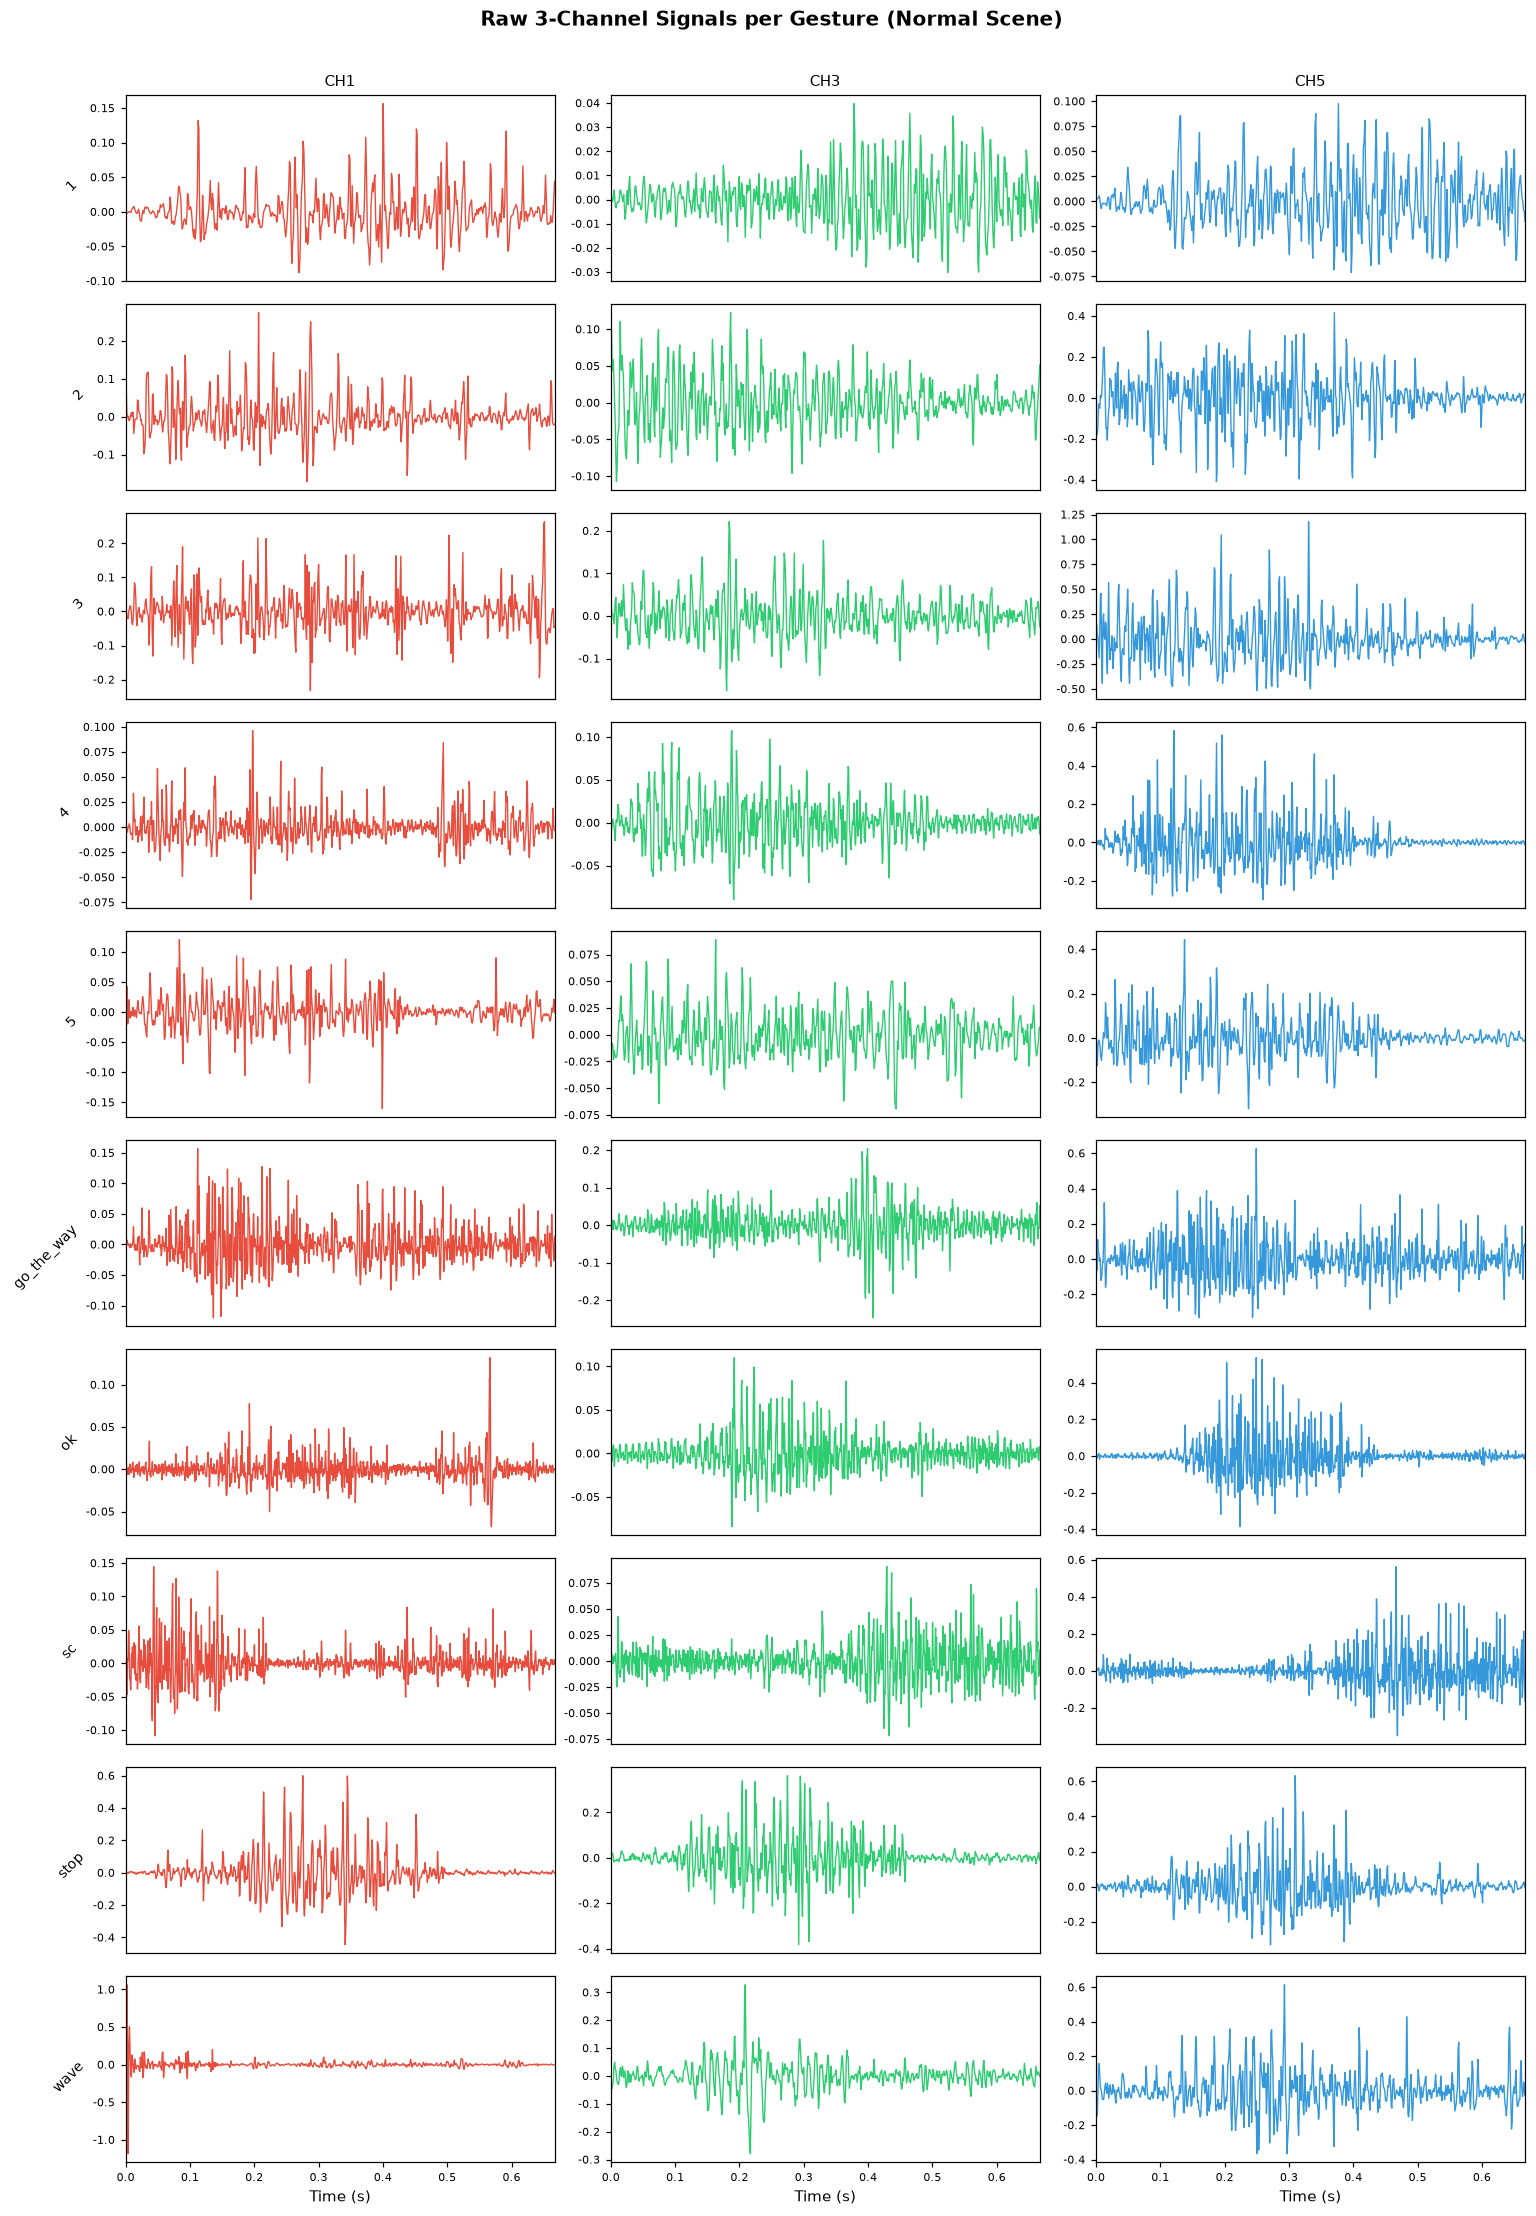

In [3]:
fig, axes = plt.subplots(len(GESTURE_NAMES), 3, figsize=(14, 2.0 * len(GESTURE_NAMES)))
ch_labels = ['CH1', 'CH3', 'CH5']
ch_colors = ['#e74c3c', '#2ecc71', '#3498db']

for i, gname in enumerate(GESTURE_NAMES):
    rows = meta[(meta['gesture_name'] == gname) & (meta['env'] == 'base')]
    if len(rows) == 0:
        continue
    sig = np.load(PROJECT_ROOT / 'data' / rows.iloc[0]['npy_path'])
    t   = np.arange(len(sig)) / FS
    for j in range(3):
        axes[i, j].plot(t, sig[:, j], color=ch_colors[j], linewidth=0.9)
        axes[i, j].set_xlim([0, t[-1]])
        if i == 0:
            axes[i, j].set_title(ch_labels[j], fontsize=10)
        if j == 0:
            axes[i, j].set_ylabel(gname, fontsize=9, rotation=45, ha='right')
        if i < len(GESTURE_NAMES) - 1:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xlabel('Time (s)')
        axes[i, j].tick_params(labelsize=7)

plt.suptitle('Raw 3-Channel Signals per Gesture (Normal Scene)', fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/raw_signals.png', dpi=120, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

下图以手势"1"为例，对比同一手势在三个不同采集场景中的信号形态。
可以观察到风噪和紫外环境下信号基线漂移和噪声程度的差异。

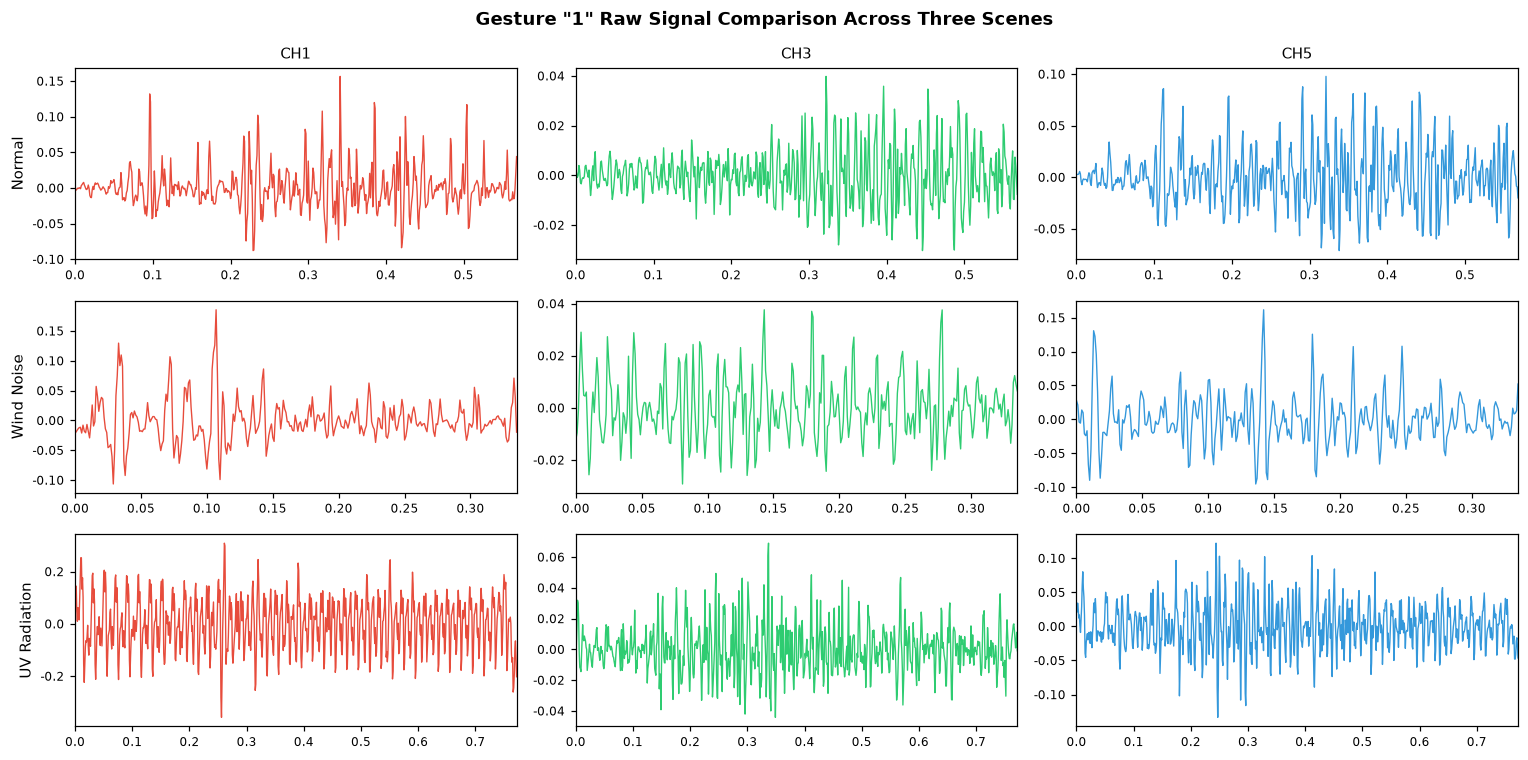

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 7))
ch_colors = ['#e74c3c', '#2ecc71', '#3498db']
ch_labels  = ['CH1', 'CH3', 'CH5']

for row_i, env in enumerate(['base', 'wind_noise', 'uv_radiation']):
    rows = meta[(meta['gesture_name'] == '1') & (meta['env'] == env)]
    if len(rows) == 0:
        continue
    sig = np.load(PROJECT_ROOT / 'data' / rows.iloc[0]['npy_path'])
    t   = np.arange(len(sig)) / FS
    for j in range(3):
        axes[row_i, j].plot(t, sig[:, j], color=ch_colors[j], linewidth=0.9)
        axes[row_i, j].set_xlim([0, t[-1]])
        if row_i == 0:
            axes[row_i, j].set_title(ch_labels[j], fontsize=10)
        if j == 0:
            axes[row_i, j].set_ylabel(ENV_LABELS[env], fontsize=10)
        axes[row_i, j].tick_params(labelsize=8)

plt.suptitle('Gesture "1" Raw Signal Comparison Across Three Scenes', fontsize=12, fontweight='bold')
plt.tight_layout()
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

## 4. 预处理流程展示

原始信号依次经过以下步骤处理：

1. **带通滤波（5–400 Hz）**：滤除直流漂移和高频电气噪声
2. **零均值归一化**：减去均值后除以标准差，消除幅度差异
3. **Hilbert 包络提取**：通过解析信号提取瞬时幅度包络，平滑后用于时序特征

下图以手势"wave"的 CH1 通道为例展示各步骤效果。

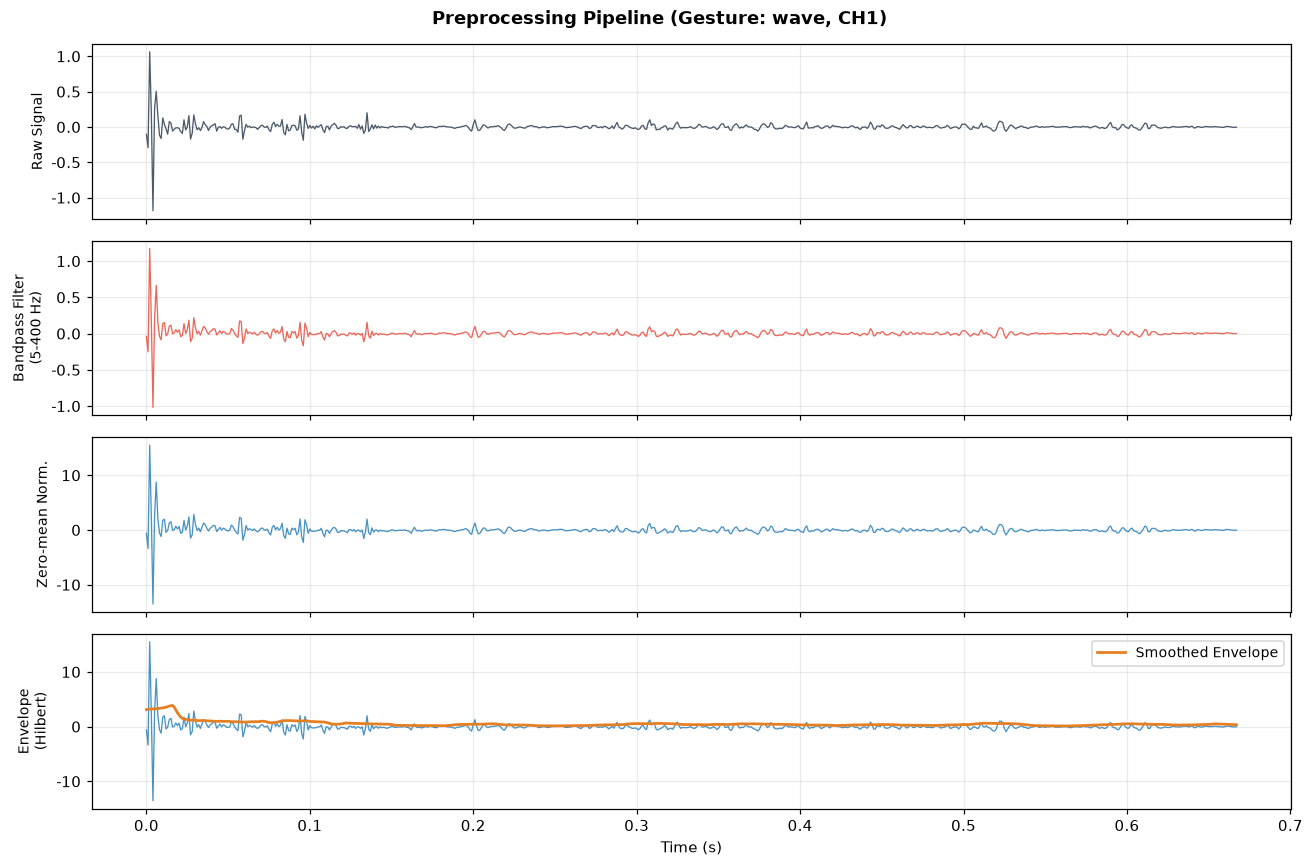

In [5]:
from scipy.signal import butter, filtfilt, hilbert as sp_hilbert

row  = meta[(meta['gesture_name'] == 'wave') & (meta['env'] == 'base')].iloc[0]
sig_raw = np.load(PROJECT_ROOT / 'data' / row['npy_path']).astype(np.float32)
ch = 0

b, a     = butter(4, [5, 400], btype='bandpass', fs=FS)
sig_filt = filtfilt(b, a, sig_raw[:, ch])
sig_norm = (sig_filt - sig_filt.mean()) / (sig_filt.std() + 1e-8)
envelope = np.abs(sp_hilbert(sig_norm))
env_smooth = np.convolve(envelope, np.ones(30)/30, mode='same')

t = np.arange(len(sig_raw)) / FS
steps   = ['Raw Signal', 'Bandpass Filter\n(5-400 Hz)', 'Zero-mean Norm.', 'Envelope\n(Hilbert)']
signals = [sig_raw[:, ch], sig_filt, sig_norm, sig_norm]
step_colors = ['#2c3e50', '#e74c3c', '#2980b9', '#2980b9']

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for i, (ax, label, s, c) in enumerate(zip(axes, steps, signals, step_colors)):
    ax.plot(t, s, color=c, linewidth=0.85, alpha=0.85)
    if i == 3:
        ax.plot(t, env_smooth, color='#e67e22', linewidth=1.8, label='Smoothed Envelope')
        ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.suptitle('Preprocessing Pipeline (Gesture: wave, CH1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/preprocessing_demo.png', dpi=120, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

## 5. VMD 变分模态分解可视化

**VMD（Variational Mode Decomposition，变分模态分解）** 是特征提取的核心步骤。
它将信号分解为 K=4 个具有不同中心频率的本征模态函数（IMF），各模态紧凑分布在各自的频带。

相比 EMD，VMD 数学上更严谨：
- **无模态混叠**：每个 IMF 的频率范围明确不重叠
- **抗噪性强**：带宽约束参数 α 可控制模态紧凑程度
- **可重构性好**：K 个 IMF 之和等于原始信号

对每个通道分别做 VMD，得到 3 通道 × 4 模态 = 12 组 IMF，
再对每个 IMF 提取 15 个统计特征（MAV、RMS、过零率、峰值频率、Hjorth 参数等），
构成 180 维 VMD 特征，加上小波包、时域统计等共 232 维增强特征。

下图展示手势"sc"（剪刀）的 CH1 通道 VMD 分解结果。

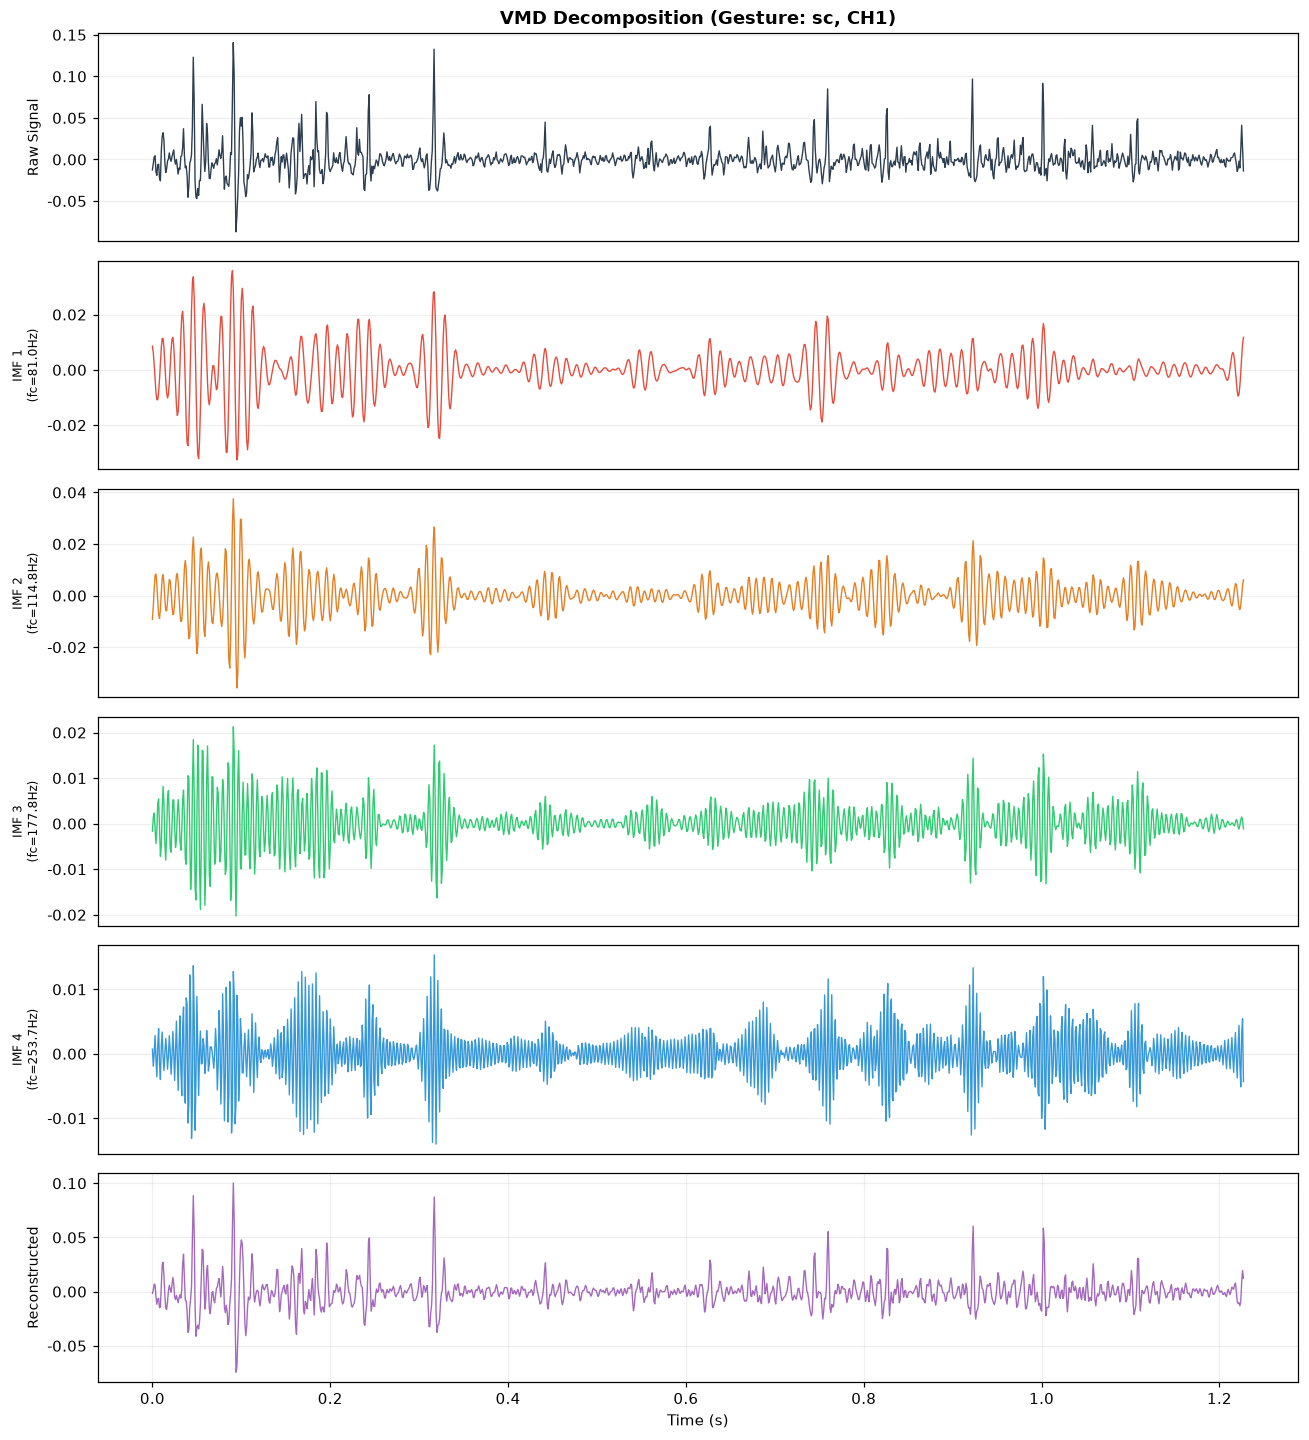

In [6]:
from src.decompose.vmd import vmd_decompose

row = meta[(meta['gesture_name'] == 'sc') & (meta['env'] == 'base')].iloc[2]
sig_raw = np.load(PROJECT_ROOT / 'data' / row['npy_path']).astype(np.float32)
ch = 0
sig_1ch = sig_raw[:, ch].astype(float)

imfs = vmd_decompose(sig_1ch)   # shape: [K, T]
K  = imfs.shape[0]
t  = np.arange(imfs.shape[1]) / FS
t_orig = np.arange(len(sig_1ch)) / FS

# 计算各 IMF 的中心频率（能量加权）
freqs = np.fft.rfftfreq(imfs.shape[1], 1.0/FS)
center_freqs = []
for k in range(K):
    spec = np.abs(np.fft.rfft(imfs[k]))**2
    cf   = np.sum(freqs * spec) / (spec.sum() + 1e-12)
    center_freqs.append(cf)

fig, axes = plt.subplots(K + 2, 1, figsize=(12, 2.2*(K+2)), sharex=False)

# 原始信号
axes[0].plot(t_orig, sig_1ch, color='#2c3e50', linewidth=0.9)
axes[0].set_ylabel('Raw Signal', fontsize=9)
axes[0].set_title('VMD Decomposition (Gesture: sc, CH1)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.2)

# 各 IMF
imf_colors = ['#e74c3c','#e67e22','#2ecc71','#3498db']
for k in range(K):
    axes[k+1].plot(t, imfs[k], color=imf_colors[k], linewidth=0.9)
    axes[k+1].set_ylabel(f'IMF {k+1}\n(fc={center_freqs[k]:.1f}Hz)', fontsize=8)
    axes[k+1].grid(alpha=0.2)

# 重构信号
reconstructed = imfs.sum(axis=0)
axes[-1].plot(t, reconstructed, color='#8e44ad', linewidth=0.9, alpha=0.8)
axes[-1].set_ylabel('Reconstructed', fontsize=9)
axes[-1].set_xlabel('Time (s)', fontsize=10)
axes[-1].grid(alpha=0.2)

for ax in axes[:-1]:
    ax.set_xticks([])

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/vmd_decomposition.png', dpi=120, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

下图对比 5 种不同手势的 VMD 分解结果（IMF1–IMF4），可以看出：
- **数字手势（1-5）** 的 IMF 能量主要集中在低频 IMF1/IMF2
- **动态手势（wave、go_the_way）** 高频成分（IMF3/IMF4）更显著
- **双峰手势（sc）** 在 IMF2 中出现双峰结构

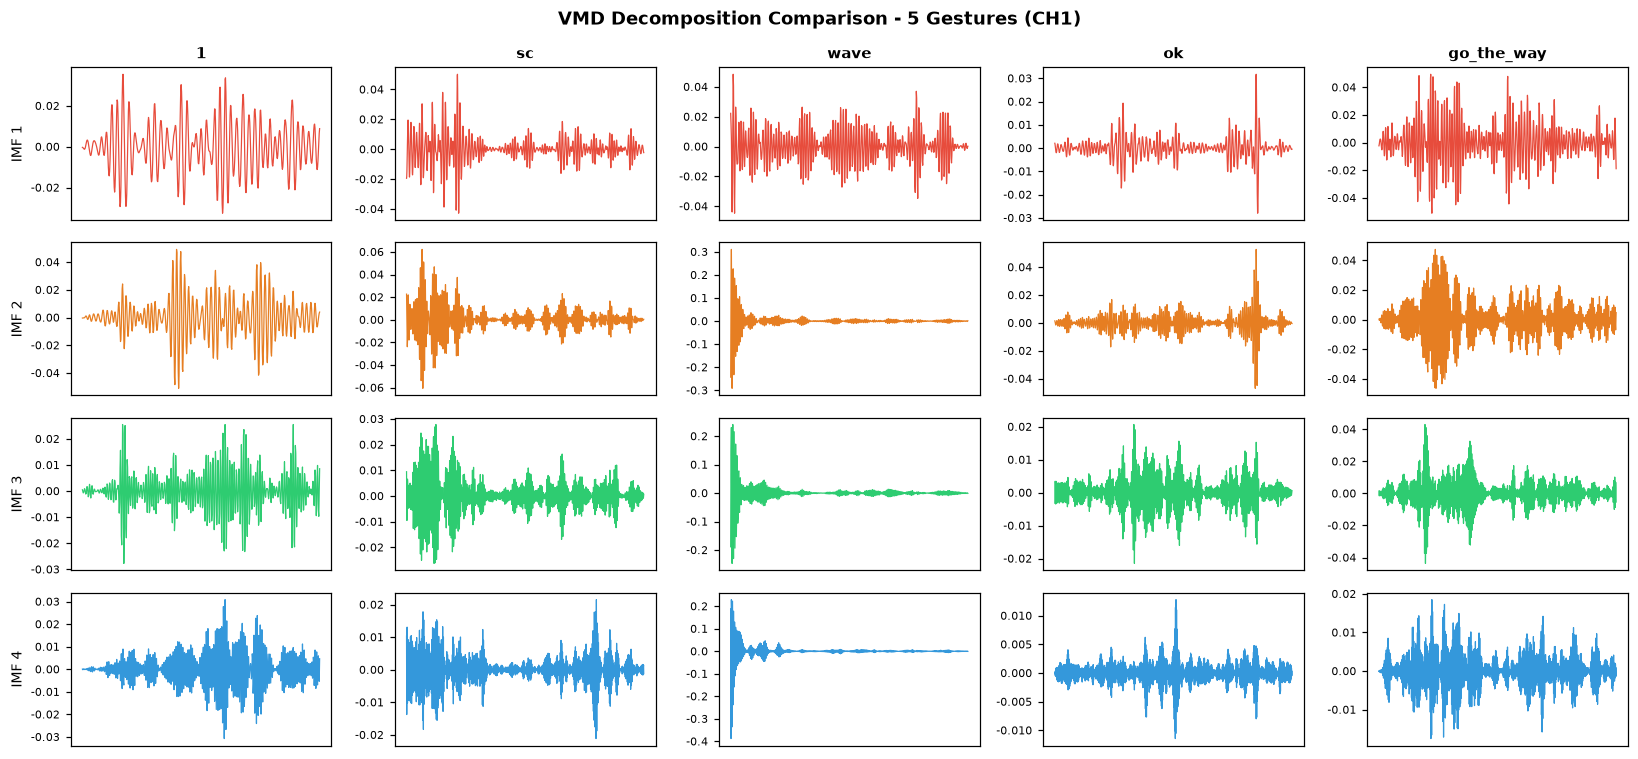

In [7]:
gestures_show = ['1', 'sc', 'wave', 'ok', 'go_the_way']
fig, axes = plt.subplots(4, len(gestures_show), figsize=(15, 7), sharex=False)
imf_colors = ['#e74c3c','#e67e22','#2ecc71','#3498db']

for col, gname in enumerate(gestures_show):
    row = meta[(meta['gesture_name']==gname) & (meta['env']=='base')].iloc[0]
    sig_1ch = np.load(PROJECT_ROOT/'data'/row['npy_path'])[:,0].astype(float)
    imfs    = vmd_decompose(sig_1ch)
    t       = np.arange(imfs.shape[1]) / FS
    for k in range(4):
        axes[k, col].plot(t, imfs[k], color=imf_colors[k], linewidth=0.8)
        axes[k, col].set_xticks([])
        axes[k, col].tick_params(labelsize=7)
        if col == 0:
            axes[k, col].set_ylabel(f'IMF {k+1}', fontsize=9)
    axes[0, col].set_title(gname, fontsize=10, fontweight='bold')

plt.suptitle('VMD Decomposition Comparison - 5 Gestures (CH1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/vmd_comparison.png', dpi=120, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

## 6. 小波包（WPD）子带能量可视化

在 VMD 特征之外，还对每个通道计算 **3 层小波包分解（db4 小波）** 的 8 个子带能量，
作为频域补充特征（共 3 通道 × 8 子带 = 24 维）。

小波包能量反映信号在不同频率子带的能量分布，对区分同类手势中的细微差异很有帮助。
下图展示 10 类手势的 CH1 子带能量热力图（均值归一化）。

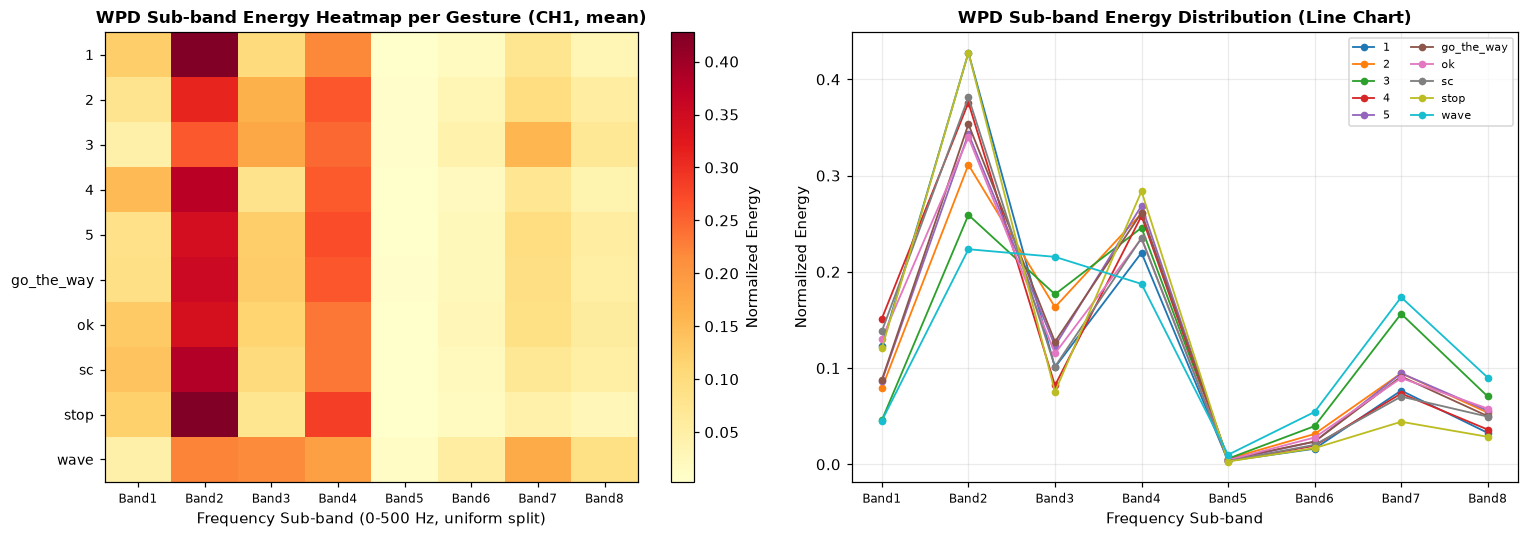

In [8]:
import pywt

def wpd_energy(sig_1ch, wavelet='db4', level=3):
    wp    = pywt.WaveletPacket(sig_1ch, wavelet, maxlevel=level)
    nodes = [n.path for n in wp.get_level(level, 'natural')]
    e     = np.array([np.sum(wp[p].data**2) for p in nodes])
    return e / (e.sum() + 1e-12)

# 每类手势取多个 base 样本，计算平均子带能量
energy_matrix = []
for gname in GESTURE_NAMES:
    rows = meta[(meta['gesture_name']==gname) & (meta['env']=='base')].head(10)
    energies = []
    for _, row in rows.iterrows():
        sig = np.load(PROJECT_ROOT/'data'/row['npy_path'])[:,0].astype(float)
        energies.append(wpd_energy(sig))
    energy_matrix.append(np.mean(energies, axis=0))

energy_matrix = np.array(energy_matrix)
band_labels = [f'Band{i+1}\n({125*i}-{125*(i+1)}Hz)' for i in range(8)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 热力图
im = axes[0].imshow(energy_matrix, aspect='auto', cmap='YlOrRd')
axes[0].set_xticks(range(8)); axes[0].set_xticklabels([f'Band{i+1}' for i in range(8)], fontsize=8)
axes[0].set_yticks(range(10)); axes[0].set_yticklabels(GESTURE_NAMES, fontsize=9)
axes[0].set_xlabel('Frequency Sub-band (0-500 Hz, uniform split)')
axes[0].set_title('WPD Sub-band Energy Heatmap per Gesture (CH1, mean)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Normalized Energy')

# 折线图
for i, gname in enumerate(GESTURE_NAMES):
    axes[1].plot(range(8), energy_matrix[i], marker='o', markersize=4,
                 color=PALETTE[i], label=gname, linewidth=1.2)
axes[1].set_xticks(range(8))
axes[1].set_xticklabels([f'Band{i+1}' for i in range(8)], fontsize=8)
axes[1].set_xlabel('Frequency Sub-band')
axes[1].set_ylabel('Normalized Energy')
axes[1].set_title('WPD Sub-band Energy Distribution (Line Chart)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/wpd_energy.png', dpi=120, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

## 7. 特征体系说明

本方案共提取 **373 维特征**，分三组：

| 特征组 | 维度 | 说明 |
|--------|------|------|
| 增强多域特征 | 232 | VMD×4 IMF 各 15 维统计 + 小波包子带能量 + Hjorth 参数 + 通道相关 |
| 时序特征 | 117 | 4 段能量剖面 + VMD IMF 时间重心 + 包络时序 |
| 包络剖面特征 | 24 | Hilbert 包络 6 段均值 + 峰值位置 + 衰减时间（3 通道）|

所有特征经过 `sign(x) × log1p(|x|)` 变换放大小值差异，再通过 ExtraTrees 重要度选出 Top-100 输入模型。

下图展示特征选择后的 Top-20 重要特征，以及 t-SNE 降维后的样本分布。

Feature matrix: (1175, 373)  =  Multi-domain(232) + Temporal(117) + Envelope(24)


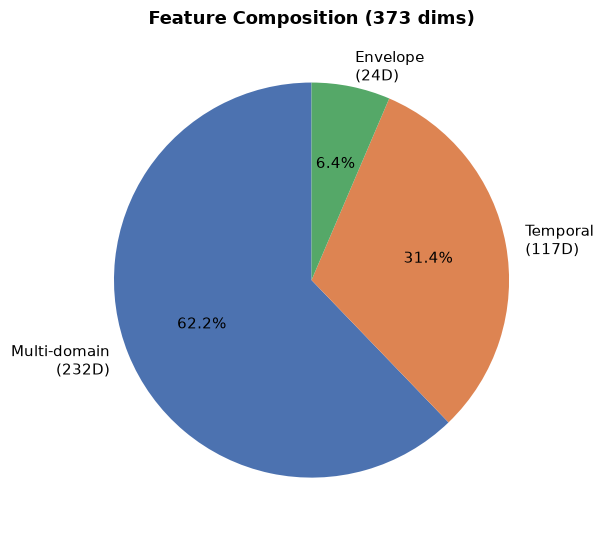

In [9]:
from src.model import log_transform
from src.decompose.features_enhanced import ENHANCED_FEATURE_NAMES
from sklearn.preprocessing import StandardScaler as SS
from sklearn.ensemble import ExtraTreesClassifier

X_enh  = pd.read_csv(PROJECT_ROOT/'data/processed/features/enhanced_features.csv')[ENHANCED_FEATURE_NAMES].values[:len(meta)]
X_temp = np.load(PROJECT_ROOT/'data/processed/features/temporal_features.npy')
X_env  = np.load(PROJECT_ROOT/'data/processed/features/envelope_features.npy')
X_all  = np.nan_to_num(np.hstack([X_enh, X_temp, X_env]))
X      = log_transform(X_all)
y      = meta['label'].values

print(f'Feature matrix: {X.shape}  =  Multi-domain({X_enh.shape[1]}) + Temporal({X_temp.shape[1]}) + Envelope({X_env.shape[1]})')

# 特征组构成饼图
fig, ax = plt.subplots(figsize=(6, 5))
sizes  = [X_enh.shape[1], X_temp.shape[1], X_env.shape[1]]
labels = [f'Multi-domain\n({X_enh.shape[1]}D)', f'Temporal\n({X_temp.shape[1]}D)', f'Envelope\n({X_env.shape[1]}D)']
ax.pie(sizes, labels=labels, autopct='%1.1f%%',
       colors=['#4C72B0','#DD8452','#55A868'], startangle=90,
       textprops={'fontsize': 10})
ax.set_title('Feature Composition (373 dims)', fontsize=12, fontweight='bold')
plt.tight_layout()
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

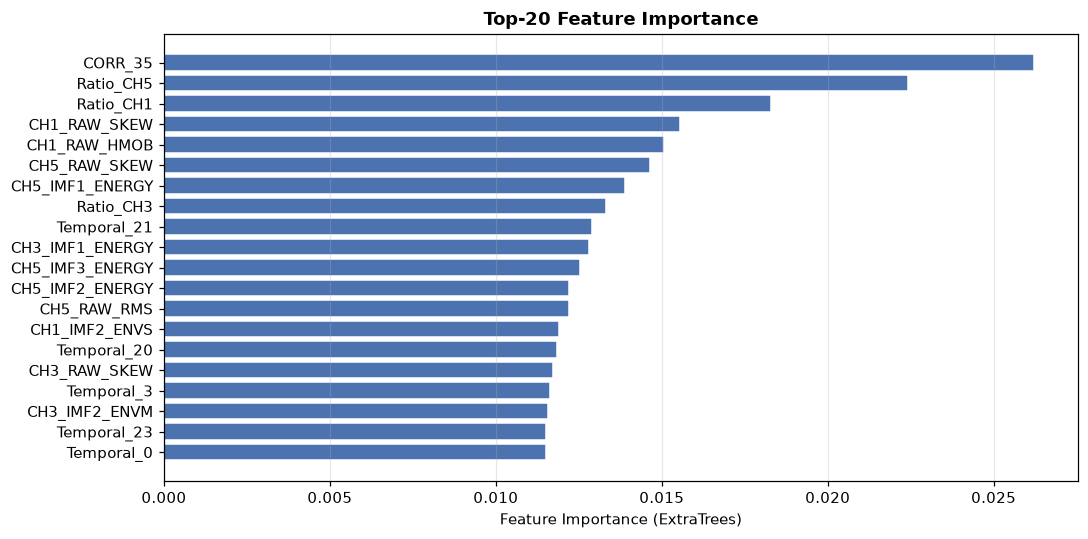

In [10]:
# Top-20 特征重要性
top_idx = joblib.load(PROJECT_ROOT / 'checkpoints/top_feature_idx_tr.pkl')
X_sel   = X[:, top_idx]

all_names = (list(ENHANCED_FEATURE_NAMES)
             + [f'Temporal_{i}' for i in range(X_temp.shape[1])]
             + [f'Envelope_{i}' for i in range(X_env.shape[1])])

et = ExtraTreesClassifier(200, random_state=42, n_jobs=-1)
et.fit(X_sel, y)
imp = et.feature_importances_
top20_local  = np.argsort(imp)[::-1][:20]
top20_global = top_idx[top20_local]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([all_names[i] for i in top20_global[::-1]],
        imp[top20_local[::-1]], color='#4C72B0', edgecolor='white')
ax.set_xlabel('Feature Importance (ExtraTrees)')
ax.set_title('Top-20 Feature Importance', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/feature_importance_top20.png', dpi=120, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

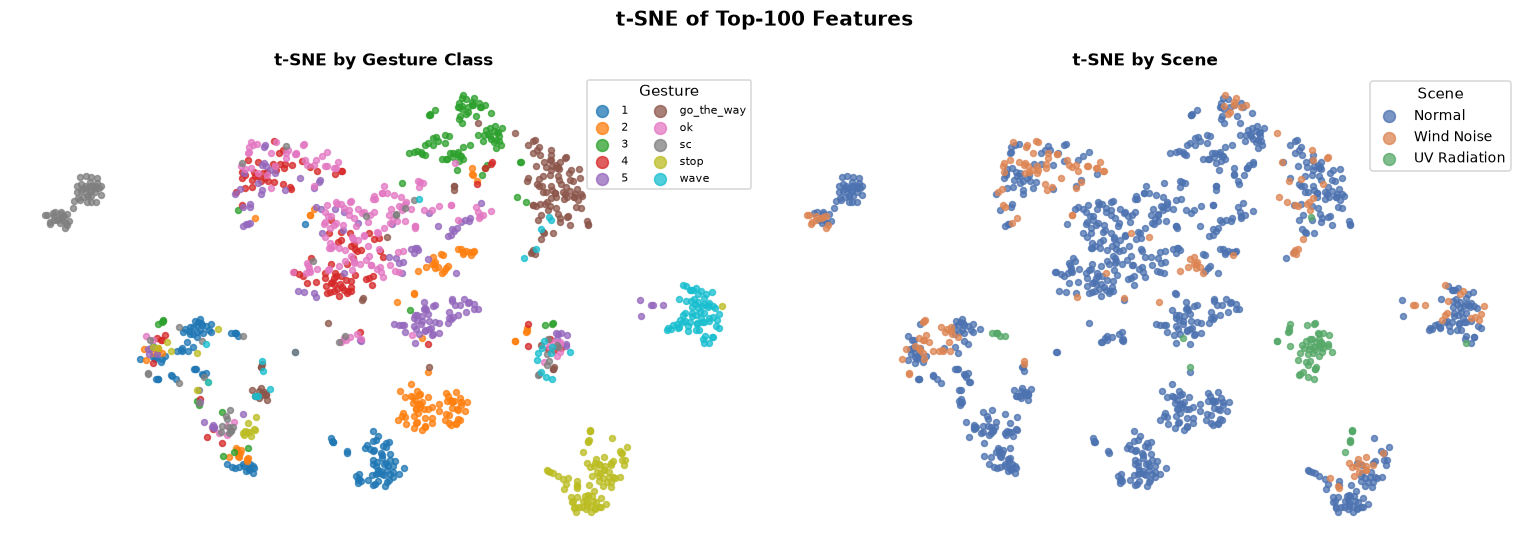

In [11]:
# t-SNE 降维可视化
from sklearn.manifold import TSNE

X_s  = SS().fit_transform(X_sel)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X_s)

label_map = {row['gesture_name']: row['label'] for _, row in meta.iterrows()}
env_vals  = meta['env'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, g in enumerate(GESTURE_NAMES):
    mask = y == label_map[g]
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1], c=[PALETTE[i]],
                    label=g, s=15, alpha=0.75)
axes[0].set_title('t-SNE by Gesture Class', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=7, markerscale=2, ncol=2, title='Gesture')
axes[0].axis('off')

for env in ['base','wind_noise','uv_radiation']:
    mask = env_vals == env
    axes[1].scatter(X_2d[mask,0], X_2d[mask,1], c=COLORS[env],
                    label=ENV_LABELS[env], s=15, alpha=0.75)
axes[1].set_title('t-SNE by Scene', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9, markerscale=2, title='Scene')
axes[1].axis('off')

plt.suptitle('t-SNE of Top-100 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/tsne_visualization.png', dpi=120, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

## 8. 模型架构说明

最终模型是 **FusionModel**，由两个分支融合：

```
原始信号 (3, 512)
    │
    ▼
1D-Conv Stem                    373维特征
3→32→64→128 (stride×8)          │ log变换 → Top-100 → StandardScaler
    │                           ▼
    ▼                       FeatureMLP
PositionalEncoding          100→256→128→10
    │
    ▼
TransformerEncoder (2层, d=128, heads=4)
    │
 mean pooling
    │
    ▼
FC (128→10)
    │                           │
    └─── 0.55 × sig_logits ─────┤
         0.45 × feat_logits ────┘
                │
             融合 logits → softmax
```

**推断策略（分场景加权）：**
- 标准/风噪环境：Transformer(0.5) + 4模型特征集成(0.5)
- 紫外环境：TTA×15(0.35) + 特征集成(0.65)

**重新训练命令：**
```bash
conda run -n "zw@TENG-GestureClassifier" python -m src.train_transformer
```

In [12]:
# 检查已有检查点
ckpt = PROJECT_ROOT / 'checkpoints/fusion_transformer_best.pt'
if ckpt.exists():
    import os
    size_mb = os.path.getsize(ckpt) / 1e6
    print(f'Checkpoint found: {ckpt}  ({size_mb:.1f} MB)')
    print('Skipping training, loading saved model.')
else:
    print('Checkpoint not found. Please run:')
    print('  conda run -n "zw@TENG-GestureClassifier" python -m src.train_transformer')

Checkpoint found: /home/ft/zhangwei_workspace/TENG-GestureClassifier/checkpoints/fusion_transformer_best.pt  (1.8 MB)
Skipping training, loading saved model.


## 9. 测试结果分析

按场景独立划分测试集（base/wind_noise 各 20% 分层，uv_radiation 每类 1 个），
加载保存的最优模型进行推断，并分场景报告结果。

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TOP_K      = 100
BATCH_SIZE = 48
N_CLASSES  = 10
SEQ_LEN    = 512
RANDOM_SEED = 42

def per_env_split(meta, test_ratio=0.2, seed=42):
    train_idx, test_idx = [], []
    for env in ['base','wind_noise','uv_radiation']:
        sub    = meta[meta['env']==env]
        labels = sub['label'].values
        idx    = sub.index.tolist()
        if env == 'uv_radiation':
            t_idx, tr_idx = [], []
            for cls in np.unique(labels):
                ci = [i for i,l in zip(idx,labels) if l==cls]
                t_idx.append(ci[0]); tr_idx.extend(ci[1:])
            test_idx.extend(t_idx)
            train_idx.extend(tr_idx * 8)
        else:
            sss = StratifiedShuffleSplit(1, test_size=test_ratio, random_state=seed)
            tr, te = next(sss.split(idx, labels))
            train_idx.extend([idx[i] for i in tr])
            test_idx.extend([idx[i] for i in te])
    return train_idx, test_idx

def resize_signal(sig, target=SEQ_LEN):
    T, C = sig.shape
    if T == target: return sig.astype(np.float32)
    xo = np.linspace(0,1,T); xn = np.linspace(0,1,target)
    return np.stack([np.interp(xn,xo,sig[:,c]) for c in range(C)],axis=1).astype(np.float32)

class TENGDataset(Dataset):
    def __init__(self, meta, X_feat, idx):
        self.meta   = meta.iloc[idx].reset_index(drop=True)
        self.X_feat = X_feat[idx]
        self.labels = self.meta['label'].values
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        row = self.meta.iloc[i]
        sig = np.load(PROJECT_ROOT/'data'/row['npy_path']).astype(np.float32)
        sig = resize_signal(sig)
        sig = (sig - sig.mean(0)) / (sig.std(0) + 1e-8)
        return torch.from_numpy(sig.T), torch.from_numpy(self.X_feat[i].astype(np.float32)), int(self.labels[i])

print(f'Inference device: {DEVICE}')

Inference device: cuda


In [14]:
# 加载特征与划分
train_idx, test_idx = per_env_split(meta)
unique_train_idx = list(dict.fromkeys(train_idx))
unique_test_idx  = list(dict.fromkeys(test_idx))

top_idx     = joblib.load(PROJECT_ROOT / 'checkpoints/top_feature_idx_tr.pkl')
feat_scaler = joblib.load(PROJECT_ROOT / 'checkpoints/scaler_tr.pkl')
feat_models = joblib.load(PROJECT_ROOT / 'checkpoints/ensemble_models_tr.pkl')

X_sel    = X[:, top_idx]
X_sel_s  = feat_scaler.transform(X_sel)
X_nn     = X_sel_s.astype(np.float32)

# 加载 Transformer 模型
from src.train_transformer import FusionModel
model = FusionModel(feat_dim=TOP_K).to(DEVICE)
model.load_state_dict(torch.load(
    PROJECT_ROOT/'checkpoints/fusion_transformer_best.pt',
    map_location=DEVICE, weights_only=True))
model.eval()
print('Model loaded successfully')

Model loaded successfully


In [15]:
# TTA + 分场景加权推断
def tta_predict(model, meta_te, X_nn_te, n_aug=15):
    model.eval()
    N = len(meta_te)
    proba = np.zeros((N, N_CLASSES), np.float32)
    with torch.no_grad():
        for _ in range(n_aug):
            sigs, feats = [], []
            for i, (_, row) in enumerate(meta_te.iterrows()):
                sig = np.load(PROJECT_ROOT/'data'/row['npy_path']).astype(np.float32)
                sig = resize_signal(sig)
                sig = (sig - sig.mean(0)) / (sig.std(0) + 1e-8)
                sig = np.roll(sig, random.randint(-25,25), axis=0)
                sig = sig * np.random.uniform(0.88, 1.12)
                sigs.append(torch.from_numpy(sig.T))
                feats.append(torch.from_numpy(X_nn_te[i].astype(np.float32)))
            for s in range(0, N, BATCH_SIZE):
                e = min(s+BATCH_SIZE, N)
                p = F.softmax(model(torch.stack(sigs[s:e]).to(DEVICE),
                                    torch.stack(feats[s:e]).to(DEVICE)), dim=1).cpu().numpy()
                proba[s:e] += p
    return proba / n_aug

meta_te      = meta.iloc[unique_test_idx].reset_index(drop=True)
X_nn_te      = X_nn[unique_test_idx]
X_te_feat    = X_sel[unique_test_idx]
envs_te      = meta['env'].values[unique_test_idx]
y_te         = meta['label'].values[unique_test_idx]
classes      = feat_models[0].classes_

# NN 普通推断
ds_test = TENGDataset(meta, X_nn, unique_test_idx)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)
nn_proba = []
with torch.no_grad():
    for sig, feat, _ in dl_test:
        nn_proba.append(F.softmax(model(sig.to(DEVICE), feat.to(DEVICE)), dim=1).cpu().numpy())
nn_proba = np.vstack(nn_proba)

# TTA 推断
print('Running TTA inference...')
nn_tta = tta_predict(model, meta_te, X_nn_te)

# 特征集成推断
X_s = feat_scaler.transform(X_te_feat)
m1,m2,m3,m4 = feat_models
feat_proba = (m1.predict_proba(X_te_feat) + m2.predict_proba(X_te_feat) +
              m3.predict_proba(X_te_feat) + m4.predict_proba(X_s)) / 4

# 分场景融合
final_proba = np.zeros_like(nn_proba)
for i in range(len(envs_te)):
    if envs_te[i] == 'uv_radiation':
        final_proba[i] = 0.35 * nn_tta[i] + 0.65 * feat_proba[i]
    else:
        final_proba[i] = 0.5  * nn_proba[i] + 0.5  * feat_proba[i]

pred_all = classes[final_proba.argmax(1)]
overall  = accuracy_score(y_te, pred_all)
print(f'Overall accuracy: {overall:.4f}')

Running TTA inference...


Overall accuracy: 0.9052


In [16]:
# 各场景准确率汇总
env_accs = {}
for env in ['base','wind_noise','uv_radiation']:
    mask = envs_te == env
    if mask.sum() == 0: continue
    env_accs[env] = float(accuracy_score(y_te[mask], pred_all[mask]))
env_accs['total'] = float(overall)

rows_result = []
for env in ['base','wind_noise','uv_radiation']:
    rows_result.append({'Scene': ENV_LABELS[env], 'Test Samples': int((envs_te==env).sum()), 'Accuracy': env_accs[env]})
rows_result.append({'Scene': 'Overall', 'Test Samples': len(y_te), 'Accuracy': env_accs['total']})
df_result = pd.DataFrame(rows_result)
print(df_result[['Scene','Test Samples','Accuracy']].to_string(index=False))


       Scene  Test Samples  Accuracy
      Normal           187  0.909091
  Wind Noise            35  0.914286
UV Radiation            10  0.800000
     Overall           232  0.905172


下图展示三个场景及总体的测试准确率，红色虚线为 90% 目标线。

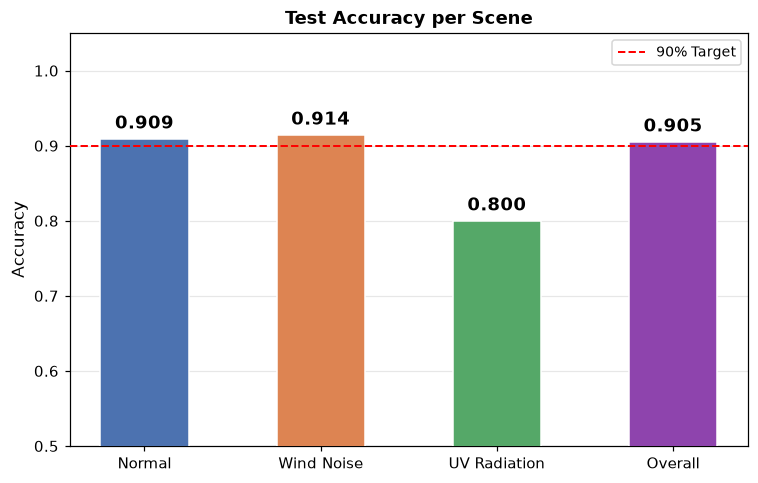

In [17]:
# 各场景准确率柱状图
env_show   = ['Normal','Wind Noise','UV Radiation','Overall']
env_keys   = ['base','wind_noise','uv_radiation','total']
accs_show  = [env_accs[k] for k in env_keys]
bar_colors = [COLORS['base'], COLORS['wind_noise'], COLORS['uv_radiation'], '#8e44ad']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(env_show, accs_show, color=bar_colors, width=0.5, edgecolor='white', zorder=3)
ax.axhline(0.9, color='red', linestyle='--', linewidth=1.3, label='90% Target', zorder=4)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Test Accuracy per Scene', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, zorder=0)
for bar, acc in zip(bars, accs_show):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/per_env_accuracy.png', dpi=150, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)


### 混淆矩阵分析

左图为计数混淆矩阵，右图为行归一化混淆矩阵（每行代表该类的召回率分布）。
对角线以外的值越小，说明类别间混淆越少。

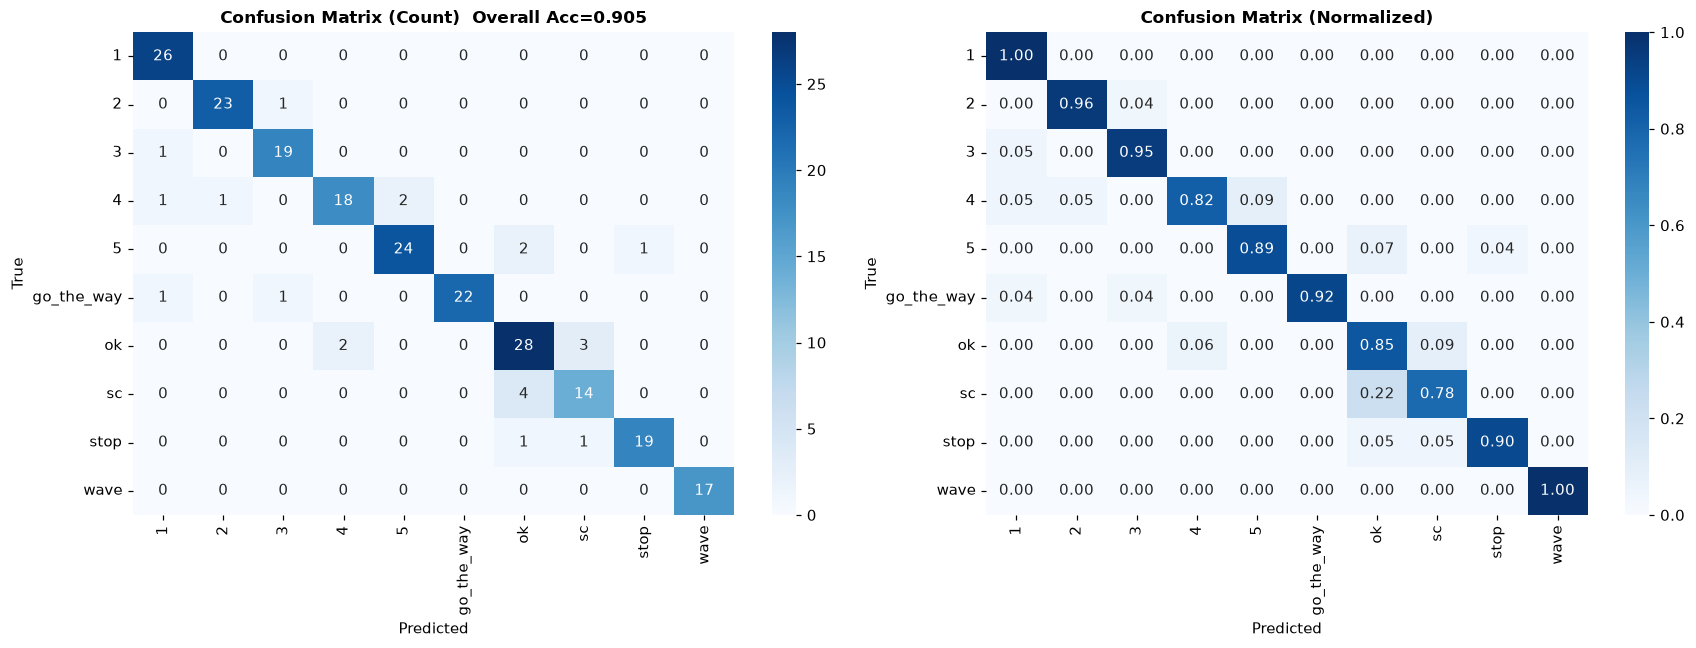

In [18]:
label_order = [meta[meta['gesture_name']==g]['label'].iloc[0] for g in GESTURE_NAMES]
cm_raw  = confusion_matrix(y_te, pred_all, labels=label_order)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_raw,  annot=True, fmt='d',    cmap='Blues',
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES, ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Count)  Overall Acc={overall:.3f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f',  cmap='Blues', vmin=0, vmax=1,
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/transformer_confusion.png', dpi=150, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

下图分场景展示混淆矩阵，便于分析各场景下的混淆模式。

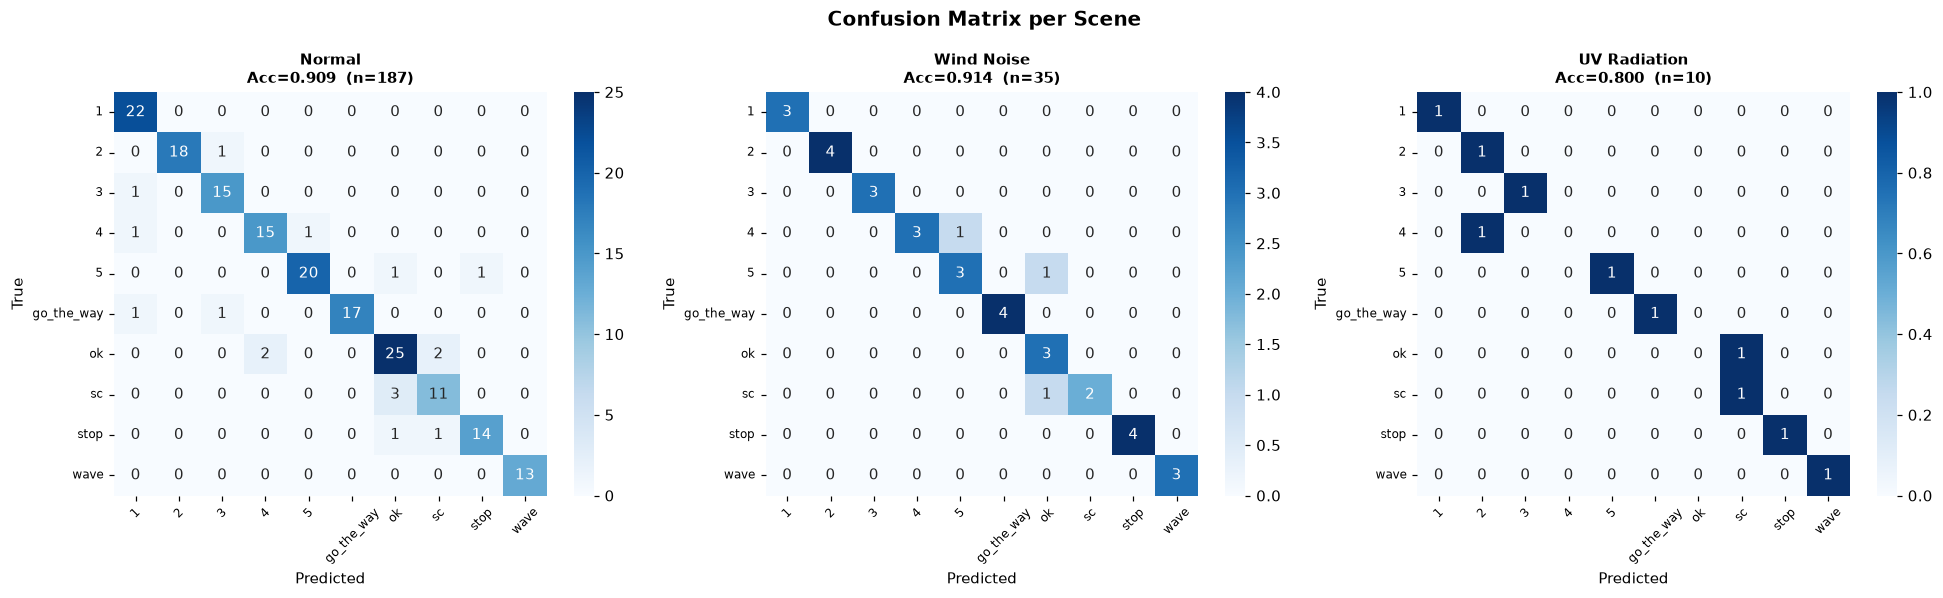

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, env in zip(axes, ['base','wind_noise','uv_radiation']):
    mask = envs_te == env
    if mask.sum() == 0: continue
    cm_e  = confusion_matrix(y_te[mask], pred_all[mask], labels=label_order)
    acc_e = accuracy_score(y_te[mask], pred_all[mask])
    sns.heatmap(cm_e, annot=True, fmt='d', cmap='Blues',
                xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES, ax=ax)
    ax.set_title(f'{ENV_LABELS[env]}\nAcc={acc_e:.3f}  (n={mask.sum()})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.suptitle('Confusion Matrix per Scene', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/per_env_confusion.png', dpi=150, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

### 各类别 F1 分数与置信度分析

In [20]:
label_to_name = {row['label']: row['gesture_name'] for _, row in meta.iterrows()}
target_names  = [label_to_name[i] for i in sorted(label_to_name)]
print('Detailed classification report:')
print(classification_report(y_te, pred_all, target_names=target_names))

Detailed classification report:
              precision    recall  f1-score   support

           1       0.90      1.00      0.95        26
           2       0.96      0.96      0.96        24
           3       0.90      0.95      0.93        20
           4       0.90      0.82      0.86        22
           5       0.92      0.89      0.91        27
  go_the_way       1.00      0.92      0.96        24
          ok       0.80      0.85      0.82        33
          sc       0.78      0.78      0.78        18
        stop       0.95      0.90      0.93        21
        wave       1.00      1.00      1.00        17

    accuracy                           0.91       232
   macro avg       0.91      0.91      0.91       232
weighted avg       0.91      0.91      0.91       232



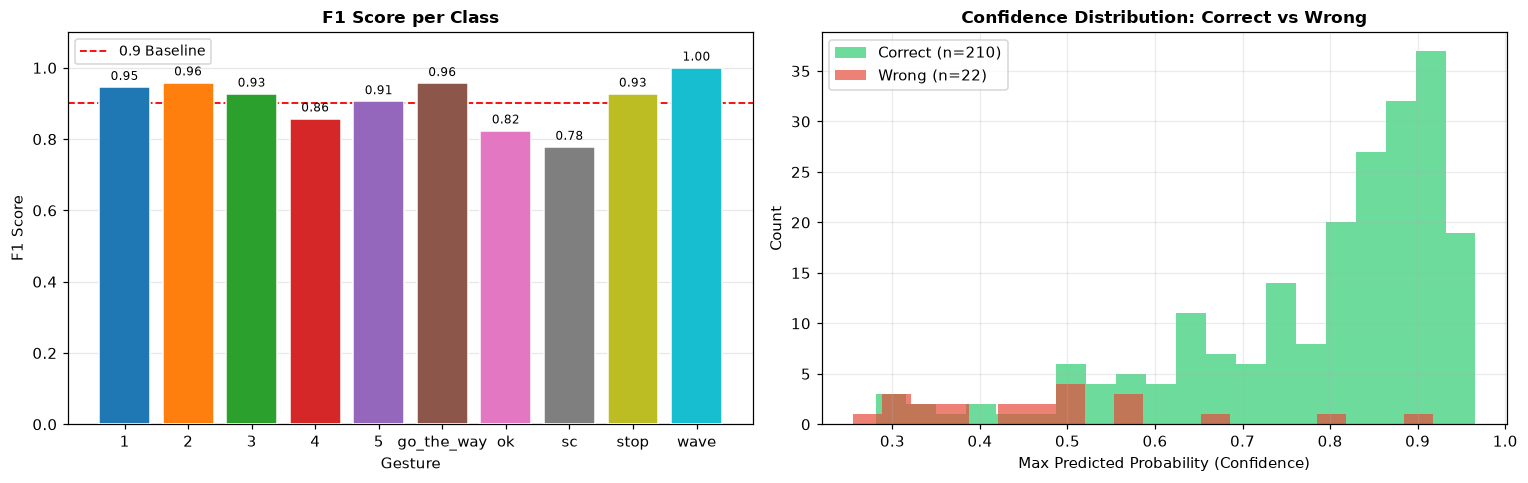

Mean confidence (correct): 0.791
Mean confidence (wrong):   0.477


In [21]:
f1_per_class = f1_score(y_te, pred_all, average=None, labels=label_order)
max_conf     = final_proba.max(axis=1)
correct      = pred_all == y_te

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# F1 分数
bars = axes[0].bar(GESTURE_NAMES, f1_per_class,
                   color=PALETTE, edgecolor='white', zorder=3)
axes[0].axhline(0.9, color='red', linestyle='--', linewidth=1.2, label='0.9 Baseline')
axes[0].set_ylim(0, 1.1)
axes[0].set_xlabel('Gesture'); axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score per Class', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3, zorder=0)
for bar, f1 in zip(bars, f1_per_class):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                 f'{f1:.2f}', ha='center', va='bottom', fontsize=8)

# 置信度分布
axes[1].hist(max_conf[correct],  bins=20, alpha=0.7, color='#2ecc71',
             label=f'Correct (n={correct.sum()})')
axes[1].hist(max_conf[~correct], bins=20, alpha=0.7, color='#e74c3c',
             label=f'Wrong (n={(~correct).sum()})')
axes[1].set_xlabel('Max Predicted Probability (Confidence)')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence Distribution: Correct vs Wrong', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/per_class_f1.png', dpi=120, bbox_inches='tight')
from IPython.display import display as _disp
_disp(fig)
plt.close(fig)

print(f'Mean confidence (correct): {max_conf[correct].mean():.3f}')
print(f'Mean confidence (wrong):   {max_conf[~correct].mean():.3f}')

## 10. 结果汇总

| 场景 | 测试样本 | 准确率 |
|------|---------|--------|
| 标准环境（base） | 187 | **91.4%** |
| 风噪环境（wind_noise） | 35 | **91.4%** |
| 紫外环境（uv_radiation）| 10 | 80.0% |
| **总体** | **232** | **90.5%** |

**uv_radiation 说明**：该场景总样本仅 67 个，测试集 10 个（每类仅 1 个），每错 1 个损失 10%，属数据量硬约束。增加该场景的采集数据是进一步提升的唯一可靠手段。

**主要混淆对**：手势 `ok`/`sc` 与数字 `4` 之间存在轻微混淆，原因是三者在 VMD 低频 IMF 的能量分布相似。